假设其继续服从U(a,b),使用最大似然估计求得：a=0.06，b=8.39

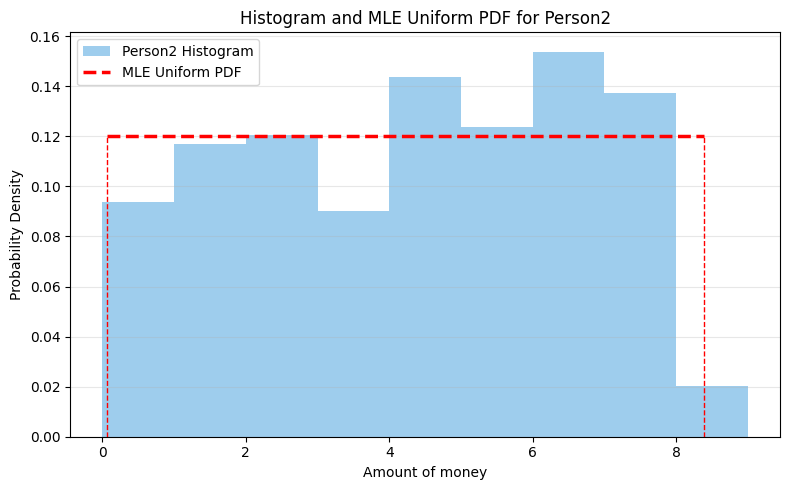

MLE Parameters for Uniform Distribution:
Estimated a (min): 0.0600
Estimated b (max): 8.3900
PDF Height: 0.1200


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 读取CSV数据
path = "envelopes.csv"
raw = pd.read_csv(path)

# 2. 按行读取数据
data = raw.iloc[1:300].reset_index(drop=True)

# 3. 获取位次列名 (假设第一列是 person1)
pos_cols = data.columns[1:15+1]
target_col = pos_cols[1]  # 只取第二个位次 (person1)

# 4. 提取数据并去除空值
values = data[target_col].dropna().values

# --- 最大似然估计 (MLE) 计算 ---
# 对于均匀分布，MLE 估计量是样本的最小值和最大值
a_mle = values.min()
b_mle = values.max()
# 均匀分布的 PDF 高度 = 1 / (b - a)
pdf_height = 1 / (b_mle - a_mle)

# 5. 绘图
plt.figure(figsize=(8, 5))

# 绘制直方图，注意必须设置 density=True
bin_width = 1
bins = np.arange(0, b_mle + bin_width, bin_width)
plt.hist(values, bins=bins, density=True, alpha=0.6, color='#5dade2', label=f'{target_col} Histogram')

# 绘制 MLE 对应的均匀分布 PDF 线
# 绘制从 a_mle 到 b_mle 的水平线
plt.hlines(y=pdf_height, xmin=a_mle, xmax=b_mle, colors='red', linestyles='--', lw=2.5, label='MLE Uniform PDF')
# 绘制两边的垂直虚线（可选，增强视觉效果）
plt.vlines(x=[a_mle, b_mle], ymin=0, ymax=pdf_height, colors='red', linestyles='--', lw=1)

# 6. 图表修饰
plt.xlabel("Amount of money")
plt.ylabel("Probability Density")
plt.title(f"Histogram and MLE Uniform PDF for {target_col}")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

# 打印估计参数
print(f"MLE Parameters for Uniform Distribution:")
print(f"Estimated a (min): {a_mle:.4f}")
print(f"Estimated b (max): {b_mle:.4f}")
print(f"PDF Height: {pdf_height:.4f}")

接下来对结果进行KS检验：
对于零假设H_0:第二个人抢到的金额真的服从U(0.06,8.39)分布，我们绘出ECDF和理论CDF，计算D值。
为消除拟合带来的偏差，再用蒙特卡洛模拟5000次真正服从U(0.06,8.39)的样本，分别计算D值，用原样本的D值估算其P-value。
若P > 0.05,认为不拒绝零假设H_0。

正在分析 Person2 的 D 值分布...


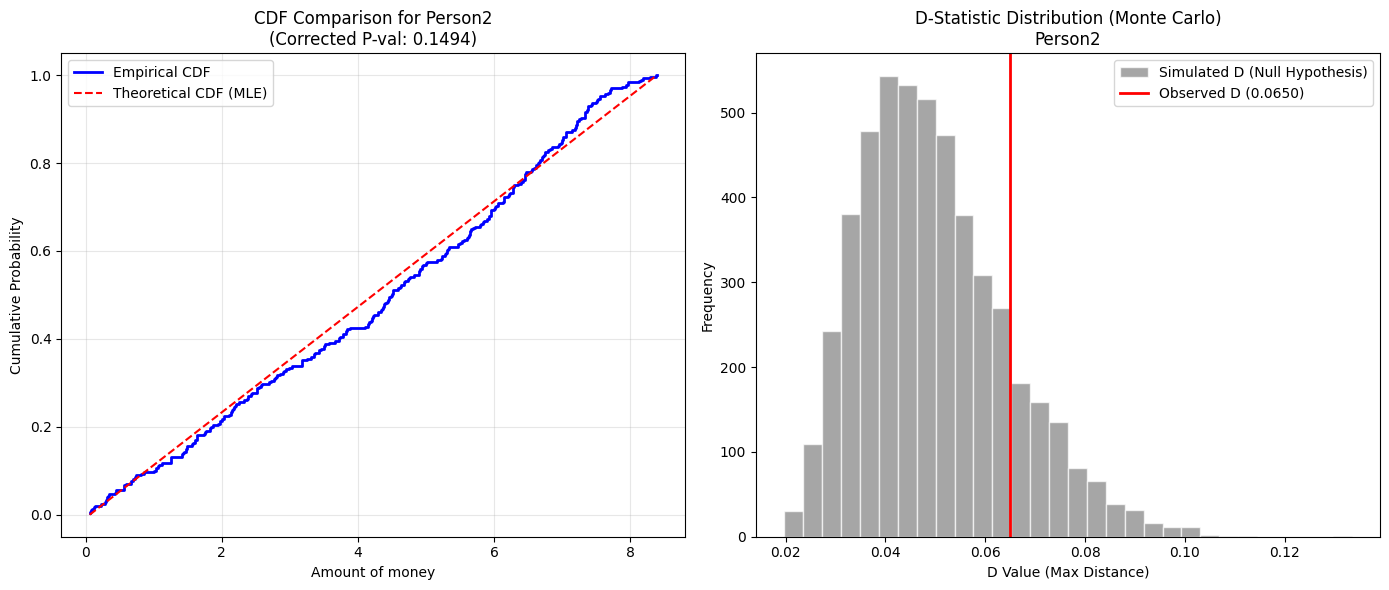

--- Person2 判定结果 ---
观测到的最大距离 D: 0.0650
修正后的 P-value: 0.1494


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# --- 1. 数据准备 (仅修改索引为 1 以指向 Person2) ---
path = "envelopes.csv"
raw = pd.read_csv(path)
data = raw.iloc[1:300].reset_index(drop=True)
pos_cols = data.columns[1:15+1]

target_col = pos_cols[1]  # 参数改动：指向第2个人
values = data[target_col].dropna().values
n_samples = len(values)

# --- 2. MLE 估计与 D 统计量计算 ---
a_mle = values.min()
b_mle = values.max()

def get_ks_dist(sample):
    a = sample.min()
    b = sample.max()
    d_stat, _ = stats.kstest(sample, 'uniform', args=(a, b - a))
    return d_stat

d_obs = get_ks_dist(values)

# --- 3. 蒙特卡洛模拟 (生成 D 值的参考分布) ---
print(f"正在分析 {target_col} 的 D 值分布...")
n_simulations = 5000
d_simulated = []
for _ in range(n_simulations):
    sim_data = np.random.uniform(0, 1, n_samples)
    d_simulated.append(get_ks_dist(sim_data))

d_simulated = np.array(d_simulated)
p_value_corrected = np.sum(d_simulated >= d_obs) / n_simulations

# --- 4. 绘图：输出 CDF 对比图 与 D值统计分析图 ---
plt.figure(figsize=(14, 6))

# 左图：CDF 对比图
plt.subplot(1, 2, 1)
values_sorted = np.sort(values)
ecdf = np.arange(1, n_samples + 1) / n_samples
plt.step(values_sorted, ecdf, label='Empirical CDF', color='blue', lw=2)
x_line = np.linspace(a_mle, b_mle, 100)
plt.plot(x_line, (x_line - a_mle)/(b_mle - a_mle), 'r--', label='Theoretical CDF (MLE)')
plt.title(f"CDF Comparison for {target_col}\n(Corrected P-val: {p_value_corrected:.4f})")
plt.xlabel("Amount of money")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(True, alpha=0.3)

# 右图：D值统计分析图 (蒙特卡洛模拟结果)
plt.subplot(1, 2, 2)
plt.hist(d_simulated, bins=30, alpha=0.7, color='gray', edgecolor='white', label='Simulated D (Null Hypothesis)')
plt.axvline(d_obs, color='red', linestyle='-', lw=2, label=f'Observed D ({d_obs:.4f})')
plt.title(f"D-Statistic Distribution (Monte Carlo)\n{target_col}")
plt.xlabel("D Value (Max Distance)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

print(f"--- {target_col} 判定结果 ---")
print(f"观测到的最大距离 D: {d_obs:.4f}")
print(f"修正后的 P-value: {p_value_corrected:.4f}")

P = 0.1494，不拒绝零假设H_0。
结论：第2个人抢到的金额服从U(0.06,8.39)分布